# Swan Consulting: Customer Churn EDA and Predictive Modelling

### Agenda

This notebook works through the Swan Teleco retention brief end to end:

1. **Data loading, cleaning & validation** - fix the raw data, check quality, validate with a schema.
2. **Demographics of churners** - who churns, what products they hold, and why they leave *(deliverable 1)*.
3. **Factors that promote retention** - what keeps customers, and the $2.50 sign-up incentive to use *(deliverable 2)*.
4. **Customer segmentation (K-means)** - data-driven churner and retained archetypes.
5. **Predictive churn model** - score every customer, producing the Top-500 mailer list *(deliverable 3)* and risk scores for all remaining customers *(deliverable 4)*.

## Importing Main Libraries and Loading Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = None

import warnings
warnings.filterwarnings('ignore') # ignore pandas warnings

PALETTE = ['#2c587e', '#a47147', '#d15115', '#dac3b4'] 

In [2]:
# Load the single customer view (Excel workbook in the project root).
data = pd.read_excel('1 - Project Data.xlsx')
data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,Competitor had better devices


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

## Cleaning

As identified below, the main issue to address are the eleven total charge entries which are a single whitespace (' ') character. These correspond to new customers which have not received their first monthly charge.

In [4]:
data['Total Charges'].value_counts()

Total Charges
20.2      11
          11
19.75      9
19.9       8
19.65      8
          ..
1419.4     1
1990.5     1
7362.9     1
346.45     1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [5]:
data[data['Total Charges'] == ' ']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,0,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,0,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No,0,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,0,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No,0,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,0,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,0,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,0,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,0,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No,0,NaN


In [6]:
# 'Total Charges' is stored as text because 11 brand-new customers (tenure 0) hold a
# blank ' ' instead of a number. Convert the whole column to numeric so the blanks
# become NaN, then fill those with 0.0 - a customer with 0 months has accrued no total
# charges yet. This is more robust than a string replace (it can't silently corrupt a
# value that happens to contain a space).
data['Total Charges'] = pd.to_numeric(data['Total Charges'], errors='coerce').fillna(0.0)

### Data quality summary

A quick check of the cleaned data. The only column with missing values is `Churn Reason` - this is expected and left as-is: a churn reason only exists for customers who actually churned, so the 5,174 blanks are simply the retained customers.

In [7]:
# Missing values, duplicates, and confirm Total Charges is now numeric.
missing = data.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0].to_string())
print('\nDuplicate rows:', data.duplicated().sum())
print('Total Charges dtype after cleaning:', data['Total Charges'].dtype)

Missing values per column:
Churn Reason    5174

Duplicate rows: 0
Total Charges dtype after cleaning: float64


In [8]:
data['CustomerID'].nunique()

7043

In [9]:
data.shape[0]

7043

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data['Churn Reason'].unique()

<ArrowStringArray>
[             'Competitor made better offer',
                                     'Moved',
             'Competitor had better devices',
 'Competitor offered higher download speeds',
              'Competitor offered more data',
                            'Price too high',
                   'Product dissatisfaction',
                   'Service dissatisfaction',
           'Lack of self-service on Website',
                       'Network reliability',
                 'Limited range of services',
  'Lack of affordable download/upload speed',
                     'Long distance charges',
                        'Extra data charges',
                                'Don't know',
          'Poor expertise of online support',
           'Poor expertise of phone support',
              'Attitude of service provider',
                'Attitude of support person',
                                  'Deceased',
                                         nan]
Length: 21, dty

In [12]:
data['Payment Method'].unique()

<ArrowStringArray>
[             'Mailed check',          'Electronic check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [13]:
df = data.copy()
df.drop(columns=['Count', 'Country', 'State', 'Lat Long', 'Churn Label'], inplace=True)

cleaned_columns = [col.replace(' ', '_').lower() for col in df.columns]
df.columns = cleaned_columns

df.head()

,customerid,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason
0,3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,Moved
2,9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,Moved
3,7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,Moved
4,0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,Competitor had better devices


In [14]:
df['churn_value'].value_counts()

churn_value
0    5174
1    1869
Name: count, dtype: int64

In [15]:
df[df['latitude'] == 37.223]

,customerid,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason
1085,2876-VBBBL,Shaver Lake,93664,37.223,-119.001021,Female,No,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.25,20.25,1,Network reliability
1526,1415-YFWLT,Shaver Lake,93664,37.223,-119.001021,Female,Yes,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.30,89.30,1,Attitude of support person
2489,9146-JRIOX,Shaver Lake,93664,37.223,-119.001021,Female,No,Yes,Yes,14,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,25.55,372.45,0,NaN
3703,1088-AUUZZ,Shaver Lake,93664,37.223,-119.001021,Male,No,Yes,Yes,56,Yes,Yes,DSL,Yes,Yes,No,Yes,No,Yes,Two year,Yes,Credit card (automatic),75.85,4261.20,0,NaN


In [16]:
df[df['zip_code'] == 93664]

,customerid,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason
1085,2876-VBBBL,Shaver Lake,93664,37.223,-119.001021,Female,No,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.25,20.25,1,Network reliability
1526,1415-YFWLT,Shaver Lake,93664,37.223,-119.001021,Female,Yes,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.30,89.30,1,Attitude of support person
2489,9146-JRIOX,Shaver Lake,93664,37.223,-119.001021,Female,No,Yes,Yes,14,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,25.55,372.45,0,NaN
3703,1088-AUUZZ,Shaver Lake,93664,37.223,-119.001021,Male,No,Yes,Yes,56,Yes,Yes,DSL,Yes,Yes,No,Yes,No,Yes,Two year,Yes,Credit card (automatic),75.85,4261.20,0,NaN


In [17]:
df.drop(columns=['latitude', 'longitude'], inplace=True)
df.head()

,customerid,city,zip_code,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason
0,3668-QPYBK,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,Moved
2,9305-CDSKC,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,Moved
3,7892-POOKP,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,Moved
4,0280-XJGEX,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,Competitor had better devices


### Validating the cleaned data

We define a small [Pydantic](https://docs.pydantic.dev/) schema describing what a valid cleaned customer row should look like, then check every row against it. If the data ever changes in a way that breaks our assumptions (a negative charge, a churn flag that isn't 0/1, an unexpected contract type), this cell raises an error instead of letting bad data flow into the model.

In [18]:
from pydantic import BaseModel, field_validator

# Schema for one cleaned customer row. We only pin the fields the analysis relies on;
# Pydantic ignores the other columns we don't list here.
class Customer(BaseModel):
    tenure_months: int
    monthly_charges: float
    total_charges: float
    contract: str
    churn_value: int

    @field_validator('monthly_charges', 'total_charges')
    @classmethod
    def not_negative(cls, v):
        assert v >= 0, 'charges cannot be negative'
        return v

    @field_validator('contract')
    @classmethod
    def known_contract(cls, v):
        assert v in {'Month-to-month', 'One year', 'Two year'}, f'unexpected contract: {v}'
        return v

    @field_validator('churn_value')
    @classmethod
    def is_binary(cls, v):
        assert v in (0, 1), 'churn_value must be 0 or 1'
        return v

# Check every row - raises if any row breaks the schema.
for record in df.to_dict('records'):
    Customer(**record)

print(f'All {len(df):,} rows passed schema validation.')

All 7,043 rows passed schema validation.


---
## EDA

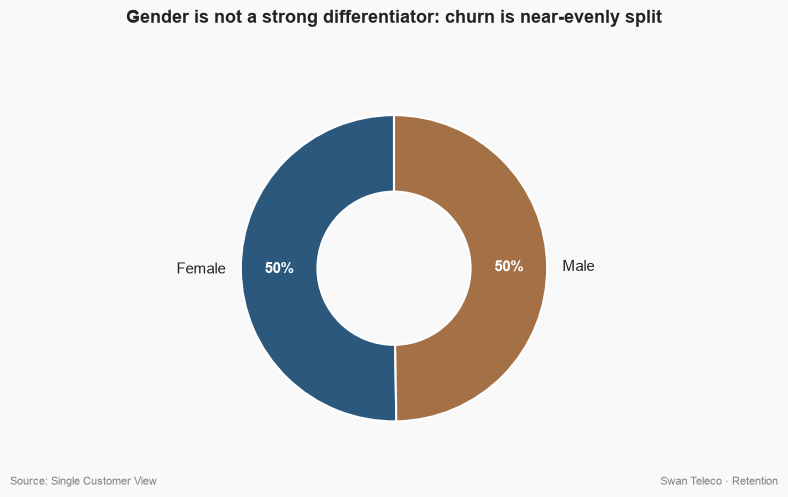

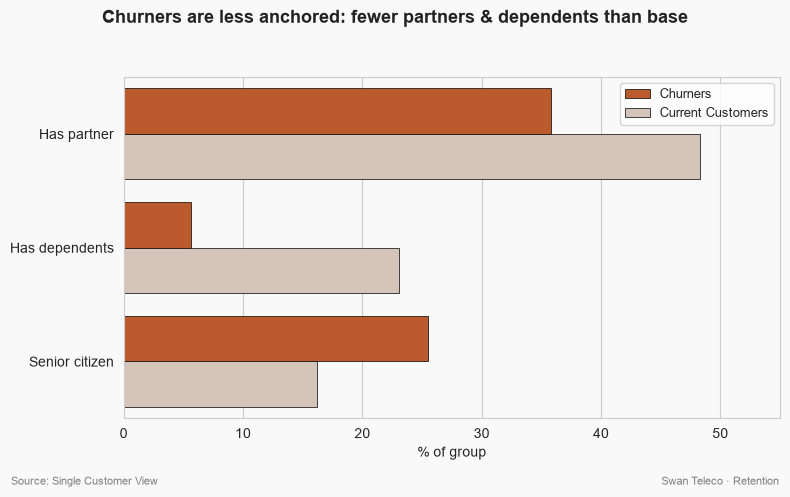

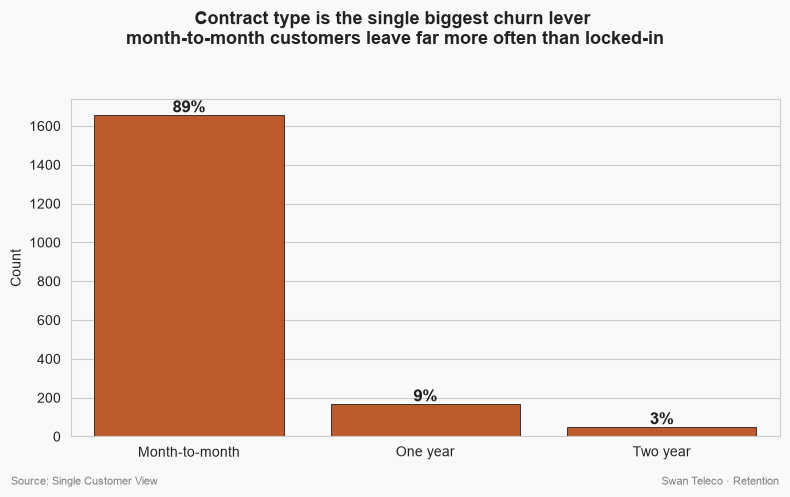

In [19]:
# EDA: Demographics of churners
# What do they look like in terms of gender, age, family makeup etc and what products do they have?

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter churned customers
churned = df[df['churn_value'] == 1].copy()
all_customers = df.copy()

sns.set_style('whitegrid')

BG_COLOUR = '#f9f9f9'

# =============================================================================
# FIGURE 1 — Churners by Gender (donut chart)
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(8, 5))
fig1.patch.set_facecolor(BG_COLOUR)
ax1.set_facecolor(BG_COLOUR)

gender_counts = churned['gender'].value_counts()
wedges, texts, autotexts = ax1.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.0f%%',
    startangle=90,
    colors=[PALETTE[0], PALETTE[1]],
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11, 'color': '#222222'},
    pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Insight headline
fig1.suptitle('Gender is not a strong differentiator: churn is near-evenly split',
              fontsize=13, fontweight='bold', color='#222222', x=0.5, y=0.97)

# Source footer
fig1.text(0.02, 0.02, 'Source: Single Customer View', fontsize=8, color='grey')
fig1.text(0.98, 0.02, 'Swan Teleco \u00b7 Retention', fontsize=8, color='grey', ha='right')

plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.show()

# =============================================================================
# FIGURE 2 — Family profile: Churners vs Base (seaborn horizontal barplot)
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(8, 5))
fig2.patch.set_facecolor(BG_COLOUR)
ax2.set_facecolor(BG_COLOUR)

categories = ['Has partner', 'Has dependents', 'Senior citizen']
fields = ['partner', 'dependents', 'senior_citizen']

churner_pcts = []
all_pcts = []
for field in fields:
    churner_pcts.append((churned[field] == 'Yes').mean() * 100)
    all_pcts.append((all_customers[field] == 'Yes').mean() * 100)

family_df = pd.DataFrame({
    'Category': categories * 2,
    'Percentage': churner_pcts + all_pcts,
    'Group': ['Churners'] * len(categories) + ['Current Customers'] * len(categories)
})

sns.barplot(
    x='Percentage', y='Category', hue='Group',
    data=family_df,
    palette=[PALETTE[2], PALETTE[3]],
    ax=ax2,
    edgecolor='black',
    linewidth=0.5
)

ax2.set_xlabel('% of group', color='#222222')
ax2.set_ylabel('')
ax2.set_xlim(0, 55)
ax2.tick_params(colors='#222222')
ax2.legend(fontsize=9)
for spine in ax2.spines.values():
    spine.set_color('#cccccc')

# Insight headline
fig2.suptitle('Churners are less anchored: fewer partners & dependents than base',
              fontsize=13, fontweight='bold', color='#222222', x=0.5, y=0.97)

# Source footer
fig2.text(0.02, 0.02, 'Source: Single Customer View', fontsize=8, color='grey')
fig2.text(0.98, 0.02, 'Swan Teleco \u00b7 Retention', fontsize=8, color='grey', ha='right')

plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.show()

# =============================================================================
# FIGURE 3 — Churners by Contract (seaborn barplot)
# =============================================================================
fig3, ax3 = plt.subplots(figsize=(8, 5))
fig3.patch.set_facecolor(BG_COLOUR)
ax3.set_facecolor(BG_COLOUR)

contract_order = ['Month-to-month', 'One year', 'Two year']
contract_df = churned['contract'].value_counts().reindex(contract_order).reset_index()
contract_df.columns = ['Contract', 'Count']
total = contract_df['Count'].sum()
contract_df['Pct'] = (contract_df['Count'] / total * 100).round(0).astype(int)

sns.barplot(
    x='Contract', y='Count',
    data=contract_df,
    color=PALETTE[2],
    ax=ax3,
    edgecolor='black',
    linewidth=0.5
)

# Add percentage labels above bars
for i, row in contract_df.iterrows():
    ax3.text(i, row['Count'] + 15, f"{row['Pct']}%",
             ha='center', fontsize=12, fontweight='bold', color='#222222')

ax3.set_xlabel('')
ax3.set_ylabel('Count', color='#222222')
ax3.tick_params(colors='#222222')
for spine in ax3.spines.values():
    spine.set_color('#cccccc')

# Insight headline
fig3.suptitle('Contract type is the single biggest churn lever \nmonth-to-month customers leave far more often than locked-in',
              fontsize=13, fontweight='bold', color='#222222', x=0.5, y=0.97)

# Source footer
fig3.text(0.02, 0.02, 'Source: Single Customer View', fontsize=8, color='grey')
fig3.text(0.98, 0.02, 'Swan Teleco \u00b7 Retention', fontsize=8, color='grey', ha='right')

plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.show()


#### What products & services do churners have?

The brief asks what products churners hold. Below is the share of churned customers subscribed to each service (a customer counts only if they actively hold it - 'No internet service' / 'No phone service' don't count).

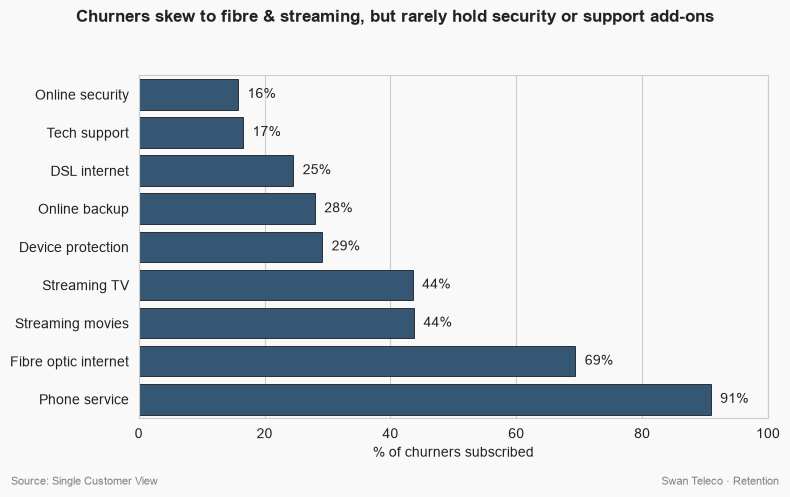

In [20]:
# What products & services do churners have?
churned = df[df['churn_value'] == 1]
BG_COLOUR = '#f9f9f9'

# % of churners who actively hold each product/service.
products = {
    'Phone service':        (churned['phone_service'] == 'Yes').mean(),
    'Fibre optic internet': (churned['internet_service'] == 'Fiber optic').mean(),
    'DSL internet':         (churned['internet_service'] == 'DSL').mean(),
    'Streaming movies':     (churned['streaming_movies'] == 'Yes').mean(),
    'Streaming TV':         (churned['streaming_tv'] == 'Yes').mean(),
    'Online backup':        (churned['online_backup'] == 'Yes').mean(),
    'Device protection':    (churned['device_protection'] == 'Yes').mean(),
    'Tech support':         (churned['tech_support'] == 'Yes').mean(),
    'Online security':      (churned['online_security'] == 'Yes').mean(),
}
svc_df = pd.DataFrame({'Service': list(products),
                       'Percentage': [v * 100 for v in products.values()]})
svc_df = svc_df.sort_values('Percentage', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG_COLOUR)
ax.set_facecolor(BG_COLOUR)

sns.barplot(x='Percentage', y='Service', data=svc_df, color=PALETTE[0],
            ax=ax, edgecolor='black', linewidth=0.5)
for i, v in enumerate(svc_df['Percentage']):
    ax.text(v + 1.5, i, f'{v:.0f}%', va='center', fontsize=10, color='#222222')

ax.set_xlabel('% of churners subscribed', color='#222222')
ax.set_ylabel('')
ax.set_xlim(0, 100)
ax.tick_params(colors='#222222')
for spine in ax.spines.values():
    spine.set_color('#cccccc')

fig.suptitle('Churners skew to fibre & streaming, but rarely hold security or support add-ons',
             fontsize=12, fontweight='bold', color='#222222', x=0.5, y=0.97)
fig.text(0.02, 0.02, 'Source: Single Customer View', fontsize=8, color='grey')
fig.text(0.98, 0.02, 'Swan Teleco \u00b7 Retention', fontsize=8, color='grey', ha='right')
plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.show()

#### Why are they churning?

Only churned customers have a `churn_reason` recorded. We group the 20 detailed reasons into broad themes so the headline story is clear.

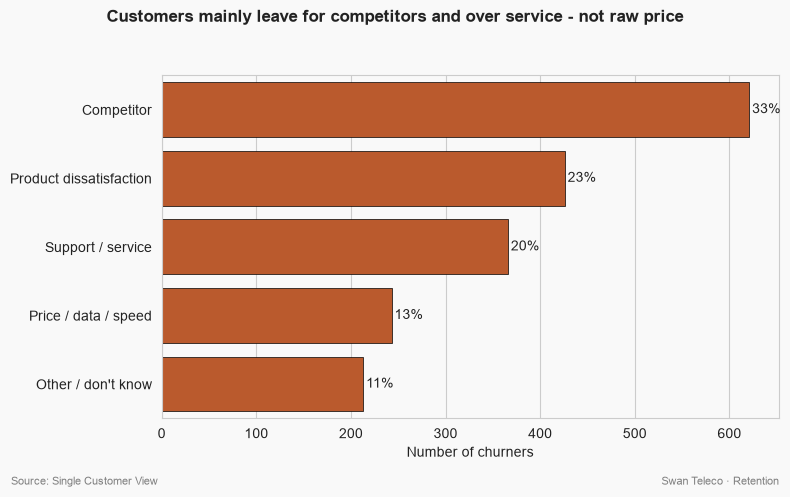

churn_reason
Competitor                 621
Product dissatisfaction    426
Support / service          366
Price / data / speed       243
Other / don't know         213


In [21]:
# Why are they churning? Group the detailed reasons into themes.
churned = df[df['churn_value'] == 1]
BG_COLOUR = '#f9f9f9'

def reason_theme(reason):
    r = str(reason).lower()
    if 'competitor' in r:
        return 'Competitor'
    if 'attitude' in r or 'expertise' in r or 'support' in r:
        return 'Support / service'
    if 'price' in r or 'charges' in r or 'data' in r or 'speed' in r:
        return 'Price / data / speed'
    if 'dissatisfaction' in r or 'reliability' in r or 'self-service' in r or 'range of services' in r:
        return 'Product dissatisfaction'
    return "Other / don't know"

reasons = churned['churn_reason'].dropna()
theme_counts = reasons.map(reason_theme).value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG_COLOUR)
ax.set_facecolor(BG_COLOUR)

sns.barplot(x=theme_counts.values, y=theme_counts.index, color=PALETTE[2],
            ax=ax, edgecolor='black', linewidth=0.5)
for i, v in enumerate(theme_counts.values):
    ax.text(v + 3, i, f'{v / len(reasons) * 100:.0f}%', va='center', fontsize=10, color='#222222')

ax.set_xlabel('Number of churners', color='#222222')
ax.set_ylabel('')
ax.tick_params(colors='#222222')
for spine in ax.spines.values():
    spine.set_color('#cccccc')

fig.suptitle('Customers mainly leave for competitors and over service - not raw price',
             fontsize=12, fontweight='bold', color='#222222', x=0.5, y=0.97)
fig.text(0.02, 0.02, 'Source: Single Customer View', fontsize=8, color='grey')
fig.text(0.98, 0.02, 'Swan Teleco \u00b7 Retention', fontsize=8, color='grey', ha='right')
plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.show()

print(theme_counts.to_string())

## Factors that promote retention

The brief also asks what makes a customer more likely to *stay*, and which single sign-up factor the new-customer team should be incentivised on.

The incentive works like this: the team can be paid a **$2.50 commission for every customer they sign up** to **one** chosen service (the brief's own example is online-security). It is a bonus paid to the sales team, **not** a discount given to the customer, and it applies to a single metric - so we have to pick the one with the biggest retention effect.

For each 'sticky' attribute we compare the churn rate of customers who **have** it against those who **don't**. Add-on services are only offered to internet customers, so those comparisons are made within the internet base.

                Factor  With  Without  Reduction (pp)
Term contract (1/2 yr)   6.8     42.7            36.0
       Online security  14.6     41.8            27.2
          Tech support  15.2     41.6            26.5
     Automatic payment  16.0     34.7            18.7
         Online backup  21.5     39.9            18.4
     Device protection  22.5     39.1            16.6


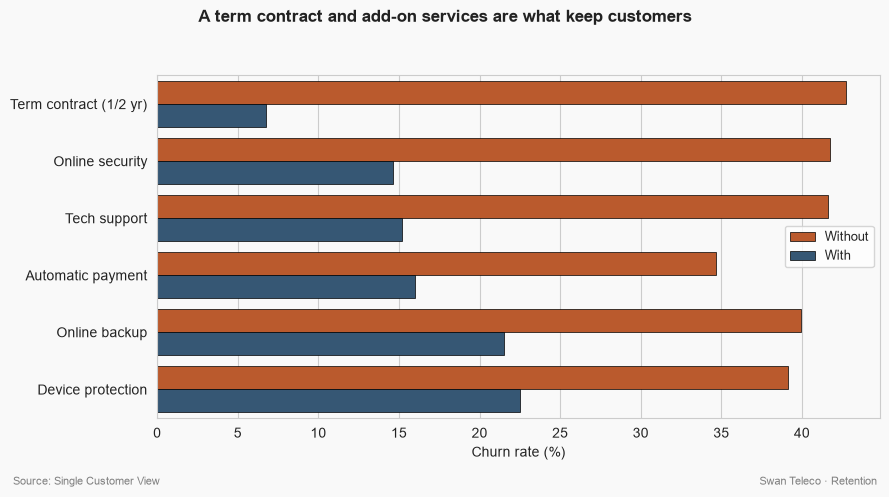

In [22]:
# Churn rate WITH vs WITHOUT each retention factor.
BG_COLOUR = '#f9f9f9'
internet = df['internet_service'] != 'No'
auto_pay = df['payment_method'].str.contains('automatic')

# each factor -> (mask of customers who HAVE it, mask of customers who DON'T)
factors = {
    'Term contract (1/2 yr)': (df['contract'] != 'Month-to-month', df['contract'] == 'Month-to-month'),
    'Online security':        (df['online_security'] == 'Yes', internet & (df['online_security'] == 'No')),
    'Tech support':           (df['tech_support'] == 'Yes',     internet & (df['tech_support'] == 'No')),
    'Automatic payment':      (auto_pay, ~auto_pay),
    'Online backup':          (df['online_backup'] == 'Yes',    internet & (df['online_backup'] == 'No')),
    'Device protection':      (df['device_protection'] == 'Yes', internet & (df['device_protection'] == 'No')),
}

rows = []
for name, (has, without) in factors.items():
    rows.append({'Factor': name,
                 'With':    df.loc[has, 'churn_value'].mean() * 100,
                 'Without': df.loc[without, 'churn_value'].mean() * 100})
retention = pd.DataFrame(rows)
retention['Reduction (pp)'] = (retention['Without'] - retention['With']).round(1)
retention = retention.sort_values('Reduction (pp)', ascending=False)
print(retention.round(1).to_string(index=False))

# Grouped bar: churn rate without (rust) vs with (navy) each factor.
plot_df = retention.melt(id_vars='Factor', value_vars=['Without', 'With'],
                         var_name='Has factor?', value_name='Churn rate')

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG_COLOUR); ax.set_facecolor(BG_COLOUR)
sns.barplot(data=plot_df, x='Churn rate', y='Factor', hue='Has factor?',
            palette=[PALETTE[2], PALETTE[0]], ax=ax, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Churn rate (%)', color='#222222'); ax.set_ylabel('')
ax.tick_params(colors='#222222'); ax.legend(title='', fontsize=9)
for spine in ax.spines.values(): spine.set_color('#cccccc')
fig.suptitle('A term contract and add-on services are what keep customers',
             fontsize=12, fontweight='bold', color='#222222', x=0.5, y=0.97)
fig.text(0.02, 0.02, 'Source: Single Customer View', fontsize=8, color='grey')
fig.text(0.98, 0.02, 'Swan Teleco \u00b7 Retention', fontsize=8, color='grey', ha='right')
plt.tight_layout(rect=[0, 0.04, 1, 0.93]); plt.show()

In [23]:
# The $2.50 question: which single sign-up metric should the sales team earn
# commission on? Size the addressable pool and check the commission pays for itself.
avg_monthly = df['monthly_charges'].mean()
internet = df['internet_service'] != 'No'
no_security = internet & (df['online_security'] == 'No')

print(f'Internet customers WITHOUT online security : {no_security.sum():,}')
print(f'Their churn rate                           : {df.loc[no_security, "churn_value"].mean() * 100:.1f}%')
print(f'Average revenue per customer               : ${avg_monthly:.2f}/month  (~${avg_monthly * 12:,.0f}/year)')
print(f'Commission per sign-up (to the sales team) : $2.50')
print(f'One retained customer funds                : {avg_monthly * 12 / 2.50:.0f} such commissions')

Internet customers WITHOUT online security : 3,498
Their churn rate                           : 41.8%
Average revenue per customer               : $64.76/month  (~$777/year)
Commission per sign-up (to the sales team) : $2.50
One retained customer funds                : 311 such commissions


#### Recommendation: pay the team the $2.50 commission on **Online Security** sign-ups

- **Online security has the largest retention effect of any single add-on** - customers who hold it churn at ~**15%** versus ~**42%** for those who don't (a ~27 percentage-point gap). A term contract is a bigger lever still, but signing someone onto a 1-2 year contract is a different (and much harder) ask than adding a service.
- The addressable pool is large and high-risk: **~3,500 internet customers don't have it**, and they churn at **~42%**.
- The commission comfortably pays for itself: at **$2.50 per sign-up**, one retained customer (~$65/month, ~$777/year) funds roughly **300** commissions.
- **If the metric were ever switched, Tech support is the closest alternative** (~26.5pp) - but the brief allows only one metric, so we recommend online security.

**So: brief the new-customer team that they earn $2.50 for every customer they sign up to online security.**

---

In [24]:
churned = df[df['churn_value'] == 1]
non_churned = df[df['churn_value'] == 0]

In [21]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# --- Feature Preparation ---
def prepare_features(group_df):
    """Encode and scale features for clustering."""
    feat = group_df.drop(columns=['customerid', 'city', 'zip_code', 'churn_value', 'churn_reason']).copy()

    # Convert total_charges to numeric
    feat['total_charges'] = pd.to_numeric(feat['total_charges'], errors='coerce')
    feat['total_charges'] = feat['total_charges'].fillna(0)

    # Binary columns: map Yes/No to 1/0
    binary_cols = ['senior_citizen', 'partner', 'dependents', 'phone_service',
                   'multiple_lines', 'online_security', 'online_backup',
                   'device_protection', 'tech_support', 'streaming_tv',
                   'streaming_movies', 'paperless_billing']

    for col in binary_cols:
        feat[col] = feat[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

    # One-hot encode multi-category columns
    feat = pd.get_dummies(feat, columns=['gender', 'internet_service', 'contract', 'payment_method'], drop_first=True, dtype='int')

    # Scale numeric features
    numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges']
    scaler = StandardScaler()
    feat[numeric_cols] = scaler.fit_transform(feat[numeric_cols])

    return feat

churned_features = prepare_features(churned)
non_churned_features = prepare_features(non_churned)

In [22]:
churned_features.head()

,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,0,0,-0.818356,1,0,1,1,0,0,0,0,1,-0.835028,-0.753126,1,0,0,0,0,0,0,1
1,0,0,1,-0.818356,1,0,0,0,0,0,0,0,1,-0.151720,-0.730114,0,1,0,0,0,0,1,0
2,0,0,1,-0.511072,1,1,0,0,1,0,1,1,1,1.022272,-0.376284,0,1,0,0,0,0,1,0
3,0,1,1,0.513209,1,1,0,0,1,1,1,1,1,1.231117,0.801058,0,1,0,0,0,0,1,0
4,0,0,1,1.588704,1,1,0,1,1,0,1,1,1,1.186509,1.853924,1,1,0,0,0,0,0,0


In [23]:
non_churned_features.head()

,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
1869,0,1,0,-1.516706,0,0,0,1,0,0,0,0,1,-1.010469,-1.081697,0,0,0,0,0,0,1,0
1870,0,0,0,-0.148061,1,0,1,0,1,0,0,0,0,-0.138796,-0.283471,1,0,0,1,0,0,0,1
1871,0,0,0,0.308154,0,0,1,0,1,1,0,0,0,-0.610014,-0.304397,1,0,0,1,0,0,0,0
1872,0,0,1,-0.645750,1,1,0,1,0,0,1,0,1,0.895310,-0.257760,1,1,0,0,0,1,0,0
1873,0,0,0,-1.143439,0,0,1,0,0,0,0,0,0,-1.013686,-0.964924,0,0,0,0,0,0,0,1


In [24]:
# --- Find Optimal k (Elbow + Silhouette) ---
def find_optimal_k(features, k_range=range(2, 9)):
    inertias = []
    silhouettes = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(features)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(features, labels))
    return list(k_range), inertias, silhouettes

# Evaluate for churned customers
k_vals_churned, inertias_c_churned, silhouettes_c_churned = find_optimal_k(churned_features)

# Evaluate for non-churned customers
k_vals_retained, inertias_c_retained, silhouettes_c_retained = find_optimal_k(non_churned_features)

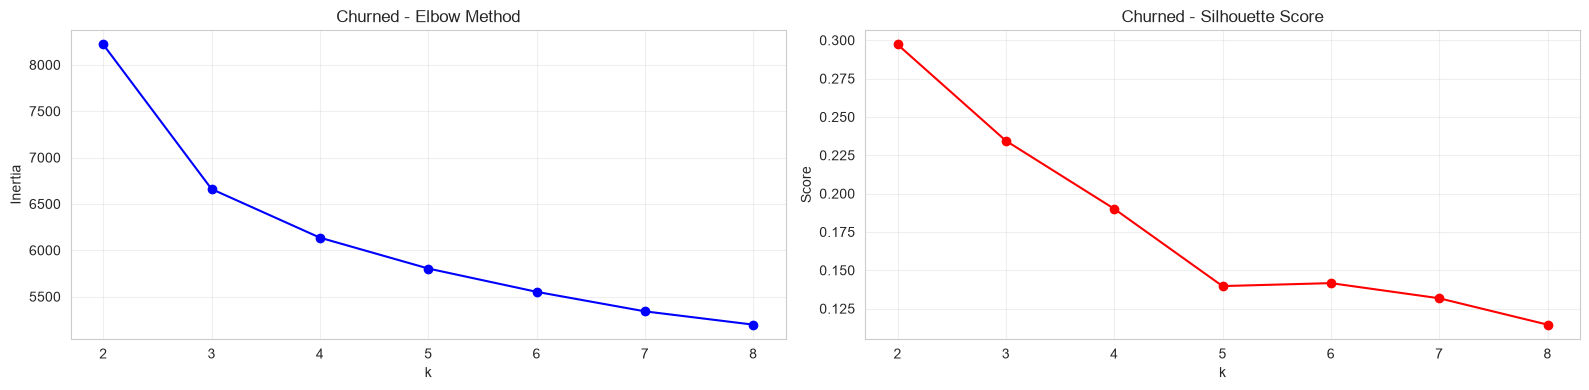

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(k_vals_churned, inertias_c_churned, 'bo-')
axes[0].set_title('Churned - Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_vals_churned, silhouettes_c_churned, 'ro-')
axes[1].set_title('Churned - Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

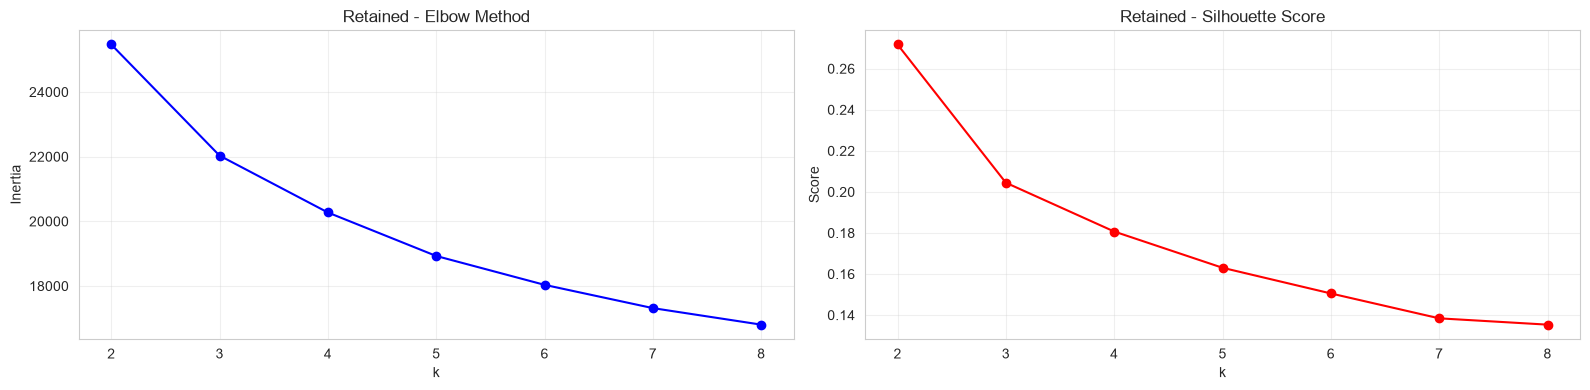

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(k_vals_retained, inertias_c_retained, 'bo-')
axes[0].set_title('Retained - Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_vals_retained, silhouettes_c_retained, 'ro-')
axes[1].set_title('Retained - Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# --- Fit Final Clusters ---
k_churned = 3  # adjust based on elbow/silhouette plots
km_churned = KMeans(n_clusters=k_churned, random_state=42, n_init=10)
churned_labels = km_churned.fit_predict(churned_features) + 1

k_non_churned = 4
km_non_churned = KMeans(n_clusters=k_non_churned, random_state=42, n_init=10)
non_churned_labels = km_non_churned.fit_predict(non_churned_features) + 1

# --- Profile Clusters ---
churned_profiled = churned.copy()
churned_profiled['cluster'] = churned_labels

non_churned_profiled = non_churned.copy()
non_churned_profiled['cluster'] = non_churned_labels

churned_profiled.head()


,customerid,city,zip_code,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason,cluster
0,3668-QPYBK,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Competitor made better offer,1
1,9237-HQITU,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,Moved,3
2,9305-CDSKC,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,Moved,3
3,7892-POOKP,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,Moved,2
4,0280-XJGEX,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,Competitor had better devices,2


In [28]:
churned_profiled.info()

<class 'pandas.DataFrame'>
RangeIndex: 1869 entries, 0 to 1868
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         1869 non-null   str    
 1   city               1869 non-null   str    
 2   zip_code           1869 non-null   int64  
 3   gender             1869 non-null   str    
 4   senior_citizen     1869 non-null   str    
 5   partner            1869 non-null   str    
 6   dependents         1869 non-null   str    
 7   tenure_months      1869 non-null   int64  
 8   phone_service      1869 non-null   str    
 9   multiple_lines     1869 non-null   str    
 10  internet_service   1869 non-null   str    
 11  online_security    1869 non-null   str    
 12  online_backup      1869 non-null   str    
 13  device_protection  1869 non-null   str    
 14  tech_support       1869 non-null   str    
 15  streaming_tv       1869 non-null   str    
 16  streaming_movies   1869 non-null   

In [29]:
non_churned_profiled.head()

,customerid,city,zip_code,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason,cluster
1869,7590-VHVEG,Los Angeles,90001,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,NaN,4
1870,5575-GNVDE,Los Angeles,90002,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,NaN,1
1871,7795-CFOCW,Los Angeles,90004,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,NaN,1
1872,1452-KIOVK,Los Angeles,90007,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0,NaN,1
1873,6713-OKOMC,Los Angeles,90008,Female,No,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,0,NaN,4


## Churned Cluster Interpretation

### Distribution

In [30]:
def cluster_distribution(profiled_df):
    """
    Show the number and percentage of customers in each cluster.
    Uses seaborn countplot and a styled pie chart.
    Returns a summary DataFrame.
    """
    palette = ['#2c587e', '#a47147', '#d15115']

    dist = profiled_df['cluster'].value_counts().sort_index()
    dist_pct = profiled_df['cluster'].value_counts(normalize=True).sort_index() * 100

    summary = pd.DataFrame({
        'count': dist,
        'percentage': dist_pct.round(2)
    })
    summary.index.name = 'cluster'

    # Set seaborn style for clean visuals
    sns.set_style('whitegrid')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Countplot (left) ---
    sns.countplot(
        x='cluster',
        data=profiled_df,
        order=sorted(profiled_df['cluster'].unique()),
        palette=palette,
        ax=axes[0],
        edgecolor='black',
        linewidth=0.8
    )
    axes[0].set_title(f'Customer Count by Cluster', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Cluster', fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)

    # Add count labels on top of each bar
    for container in axes[0].containers:
        axes[0].bar_label(container, fontsize=10, padding=3)

    # --- Pie chart (right) ---
    n_clusters = len(summary)
    # Cycle through the palette if more clusters than colors
    pie_colors = [palette[i % len(palette)] for i in range(n_clusters)]

    wedges, texts, autotexts = axes[1].pie(
        summary['percentage'],
        labels=[f'Cluster {i}' for i in summary.index],
        autopct='%1.1f%%',
        startangle=90,
        colors=pie_colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 10}
    )
    # Style the percentage text
    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_color('white')

    axes[1].set_title(f'Cluster Proportion', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return summary

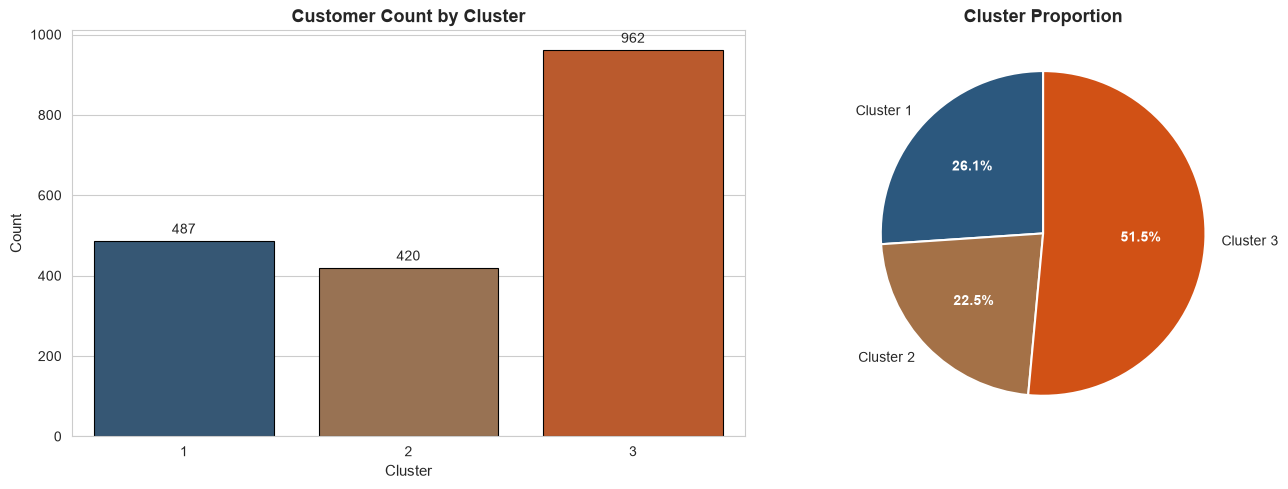

,count,percentage
cluster,,
1,487,26.06
2,420,22.47
3,962,51.47


In [31]:
cluster_distribution(churned_profiled)

### Numeric Features

In [32]:
def numeric_profile_by_cluster(profiled_df):
    """
    Compute and visualize the mean of each numeric feature per cluster.
    Produces a figure with 3 subplots (one per numeric feature) using seaborn barplots.
    Returns the aggregated DataFrame.
    """
    palette = ['#2c587e', '#a47147', '#d15115']

    # Ensure total_charges is numeric
    df_temp = profiled_df.copy()
    df_temp['total_charges'] = pd.to_numeric(df_temp['total_charges'], errors='coerce').fillna(0)

    numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges']
    agg = df_temp.groupby('cluster')[numeric_cols].mean().round(2)

    # Set seaborn style
    sns.set_style('whitegrid')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for idx, col in enumerate(numeric_cols):
        sns.barplot(
            x='cluster',
            y=col,
            data=df_temp,
            estimator='mean',
            errorbar=None,
            order=sorted(df_temp['cluster'].unique()),
            palette=palette,
            ax=axes[idx],
            edgecolor='black',
            linewidth=0.8
        )

        # Format title nicely
        col_title = col.replace('_', ' ').title()
        axes[idx].set_title(f'{col_title}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Cluster', fontsize=10)
        axes[idx].set_ylabel(f'Average {col_title}', fontsize=10)

        # Add value labels on top of each bar
        for container in axes[idx].containers:
            axes[idx].bar_label(container, fmt='%.1f', fontsize=9, padding=3)

    plt.suptitle(f'Average Numeric Features by Cluster', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return agg

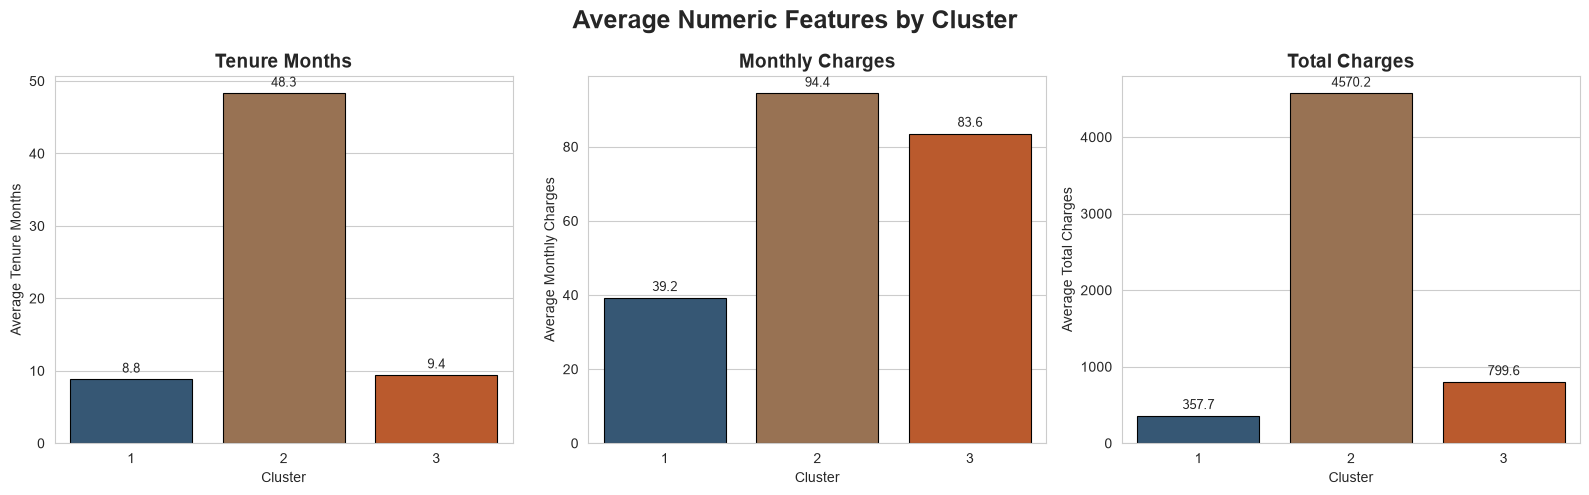

,tenure_months,monthly_charges,total_charges
cluster,,,
1,8.80,39.23,357.67
2,48.29,94.39,4570.20
3,9.39,83.56,799.65


In [33]:
numeric_profile_by_cluster(churned_profiled)

### Categorical Features

In [34]:
def categorical_profile_by_cluster(profiled_df):
    """
    For each key categorical feature, compute the percentage distribution
    within each cluster and visualize with seaborn barplots.
    Clusters are on the x-axis; category values are denoted by color (hue).
    Y-axes are fixed to 0-100%.
    Returns a dict of cross-tab DataFrames keyed by column name.
    """
    palette = ['#2c587e', '#a47147', '#d15115', '#dac3b4']

    cat_cols = ['gender', 'senior_citizen', 'partner', 'dependents',
                'phone_service', 'multiple_lines', 'internet_service',
                'online_security', 'online_backup', 'device_protection',
                'tech_support', 'streaming_tv', 'streaming_movies',
                'contract', 'paperless_billing', 'payment_method']

    cross_tabs = {}

    for col in cat_cols:
        ct = pd.crosstab(profiled_df['cluster'], profiled_df[col], normalize='index') * 100
        cross_tabs[col] = ct

    # Set seaborn style
    sns.set_style('whitegrid')

    n_cols_plot = 2
    n_rows_plot = (len(cat_cols) + n_cols_plot - 1) // n_cols_plot
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 5.5 * n_rows_plot))
    axes = axes.flatten()

    for idx, col in enumerate(cat_cols):
        # Melt the cross-tab into long format for seaborn
        ct = cross_tabs[col].copy()
        ct.index.name = 'cluster'
        ct_long = ct.reset_index().melt(id_vars='cluster', var_name=col, value_name='percentage')
        ct_long['cluster'] = ct_long['cluster'].astype(str)

        # Clusters on x-axis, category values as hue (color)
        sns.barplot(
            x='cluster',
            y='percentage',
            hue=col,
            data=ct_long,
            palette=palette[:len(ct.columns)],
            ax=axes[idx],
            edgecolor='black',
            linewidth=0.6
        )

        col_title = col.replace('_', ' ').title()
        axes[idx].set_title(f'{col_title}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Cluster', fontsize=9)
        axes[idx].set_ylabel('Percentage (%)', fontsize=9)
        axes[idx].set_ylim(0, 100)
        axes[idx].legend(title=col_title, fontsize=7, title_fontsize=8, loc='upper right')

    # Hide unused subplots
    for idx in range(len(cat_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f'Categorical Feature Distribution by Cluster',
                 fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # return cross_tabs

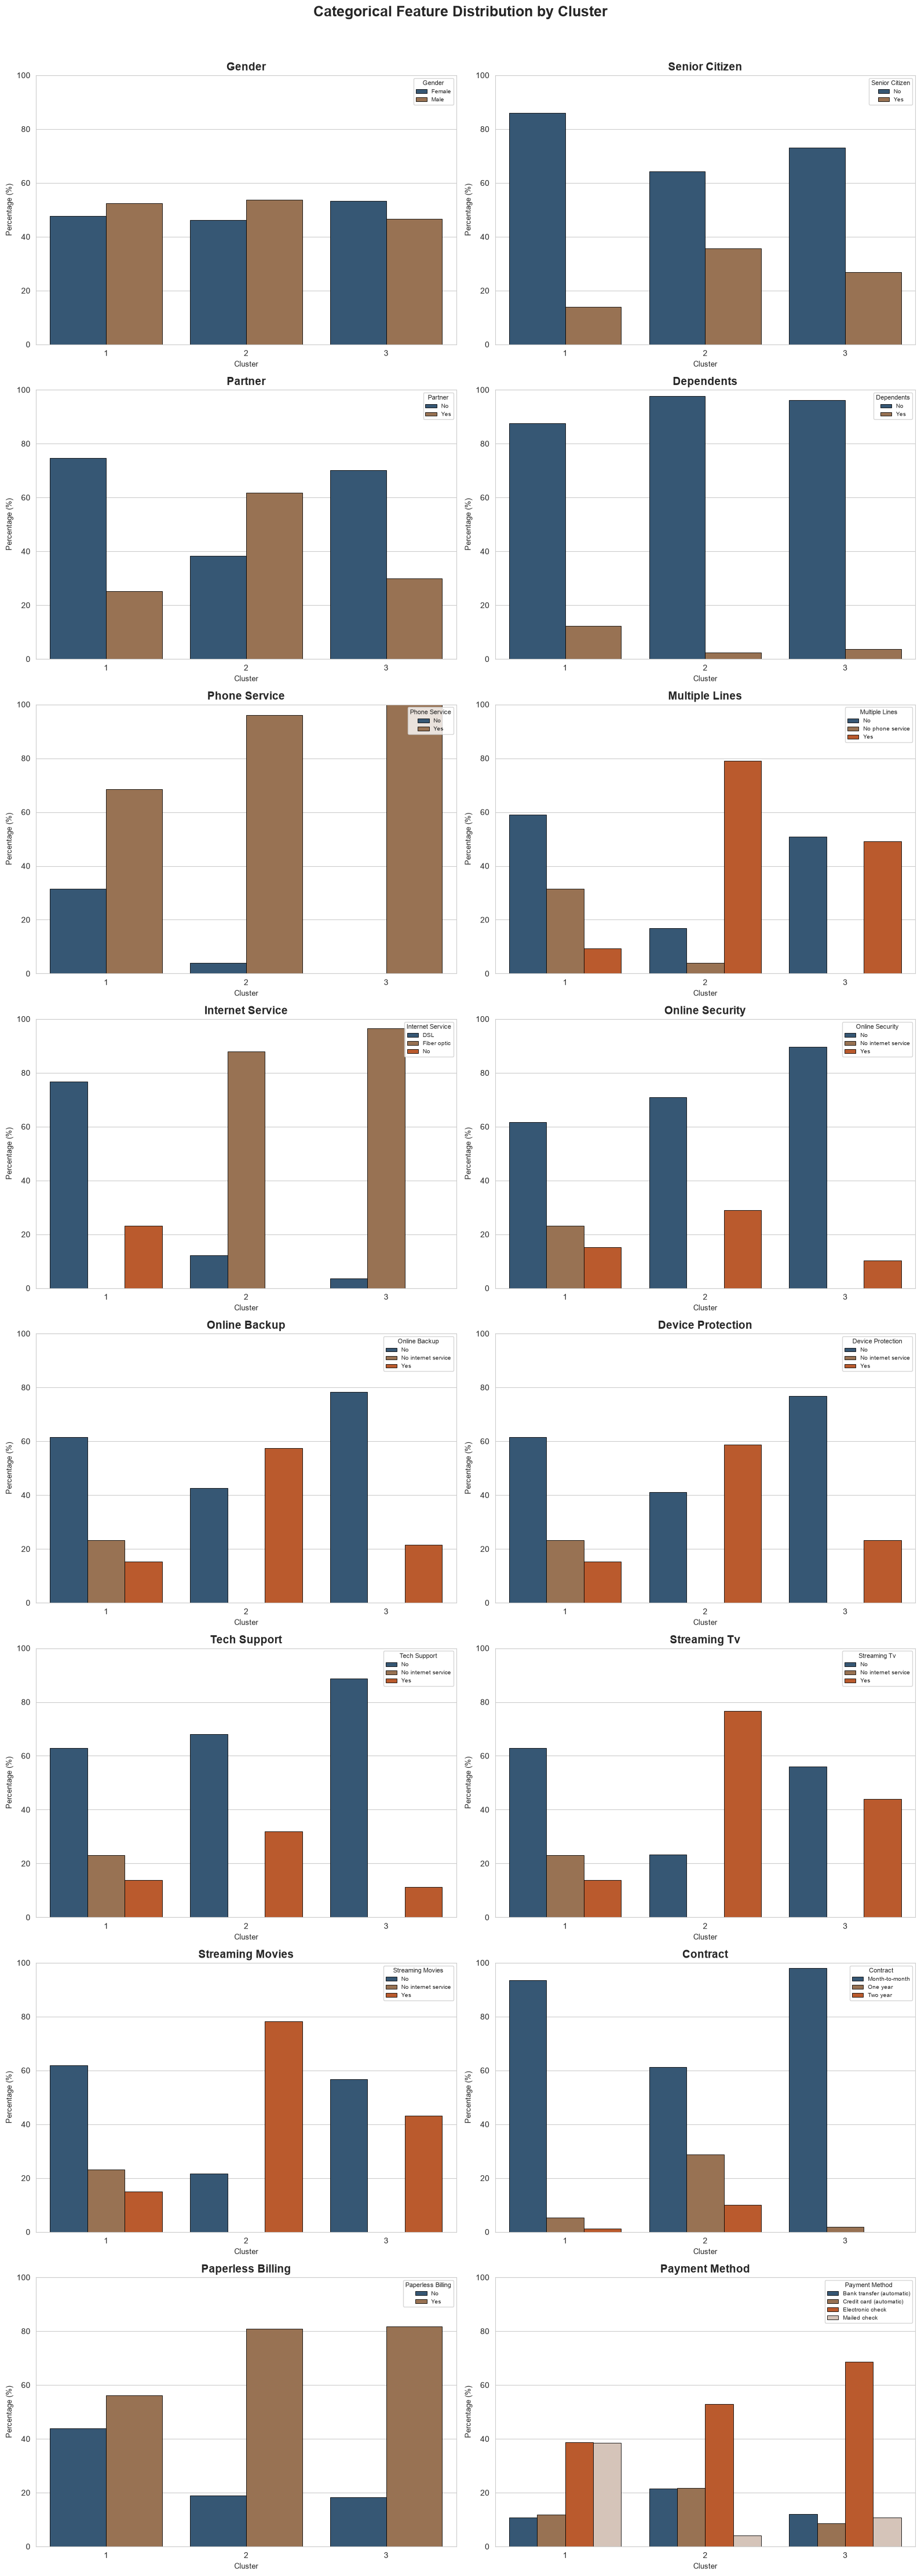

In [35]:
categorical_profile_by_cluster(churned_profiled)

#### Churned Customers: Cluster Profiles

The churned group was segmented into 3 clusters (labeled 1, 2, 3):

| Feature |	Cluster 1 |	Cluster 2 |	Cluster 3 |
|---------|-----------|-----------|-----------|
| Number of Customers | 487 (26.1%) | 420 (22.5%) | 962 (51.5%) |
| Avg Tenure (months) |	Low (~9 months) |	Moderate-Long (~4 years) |	Low (~9 months) |
| Avg Monthly Charges |	Low-medium ($39.20)	| High ($94.40) |	High ($83.60)|
| Avg Total Charges |	Low ($357.70)	| Higher ($4,570.20)	| Low-medium ($799.60) |
| Internet Service |	Mostly DSL / No internet |	Overwhelmingly Fiber optic |	Overwhelmingly Fiber optic |
| Contract |	~93% Month-to-month |	~61% Month-to-month |	~98% Month-to-month |
| Payment Method |	Split between Electronic check & Mailed check	 | ~53% Electronic check |	~69% Electronic check |
| Online Security / Tech Support |	~61% "No" (rest either have it or no internet) |	~70% "No" |	~89-90% "No" |
| Paperless Billing	| ~56% Yes |	~81% Yes |	~82% Yes |
| Senior Citizen |	~14% Yes |	~36% Yes |	~27% Yes |
| Partner / Dependents |	Low partner rate; low dependents |	Higher partner rate; very low dependents |	Low partner; very low dependents |

**Key takeaways for churned customers:**

* Cluster 3 is the most "at-risk" archetype: very short tenure, very high monthly charges, almost exclusively month-to-month contracts, fiber optic internet, paying via electronic check, and virtually no value-added services (online security, tech support, etc.). These are high-revenue but low-loyalty customers.

* Cluster 2 shares many traits with Cluster 3 (fiber optic, high charges, paperless billing, electronic check) but has somewhat longer tenure (4 years on average) and higher add-on adoption. They may represent customers who tried the service longer but still ultimately churned.

* Cluster 1 looks quite different: lower monthly charges, more DSL/no internet, more mailed-check payments, and a high concentration of month-to-month contracts. This group churns despite lower engagement with add-on features, possibly due to price sensitivity on basic services.

---
### Comparison with Retained Customers

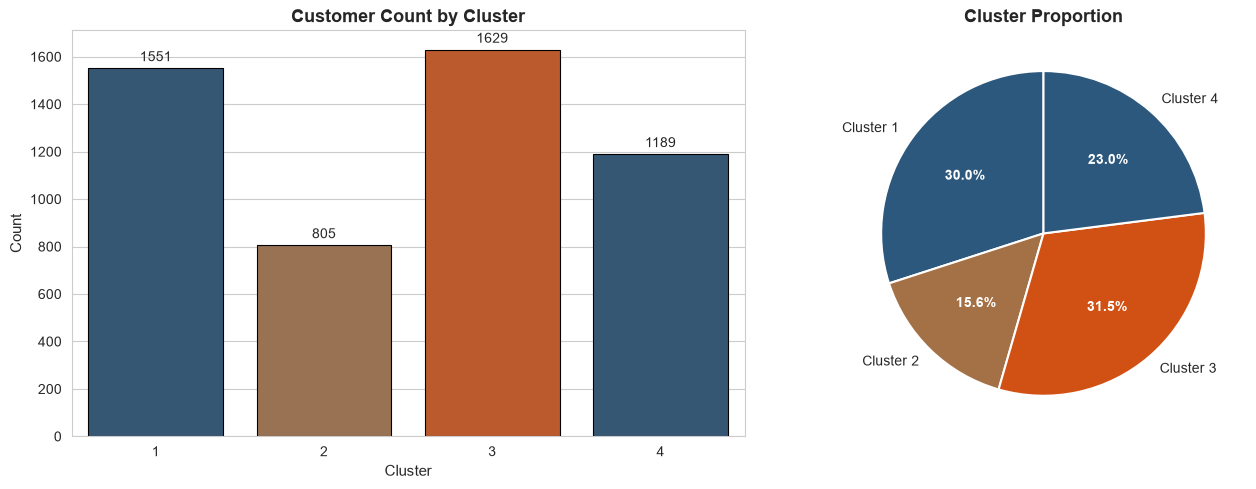

,count,percentage
cluster,,
1,1551,29.98
2,805,15.56
3,1629,31.48
4,1189,22.98


In [36]:
cluster_distribution(non_churned_profiled)

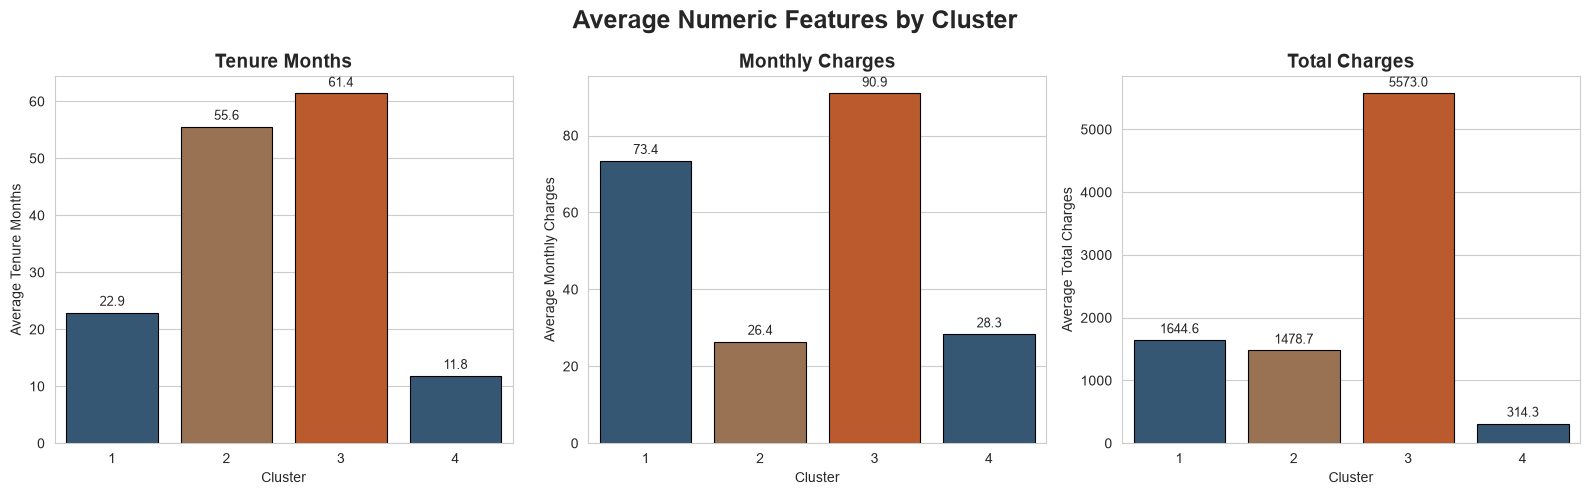

,tenure_months,monthly_charges,total_charges
cluster,,,
1,22.93,73.42,1644.56
2,55.57,26.43,1478.72
3,61.39,90.93,5573.00
4,11.84,28.34,314.35


In [37]:
numeric_profile_by_cluster(non_churned_profiled)

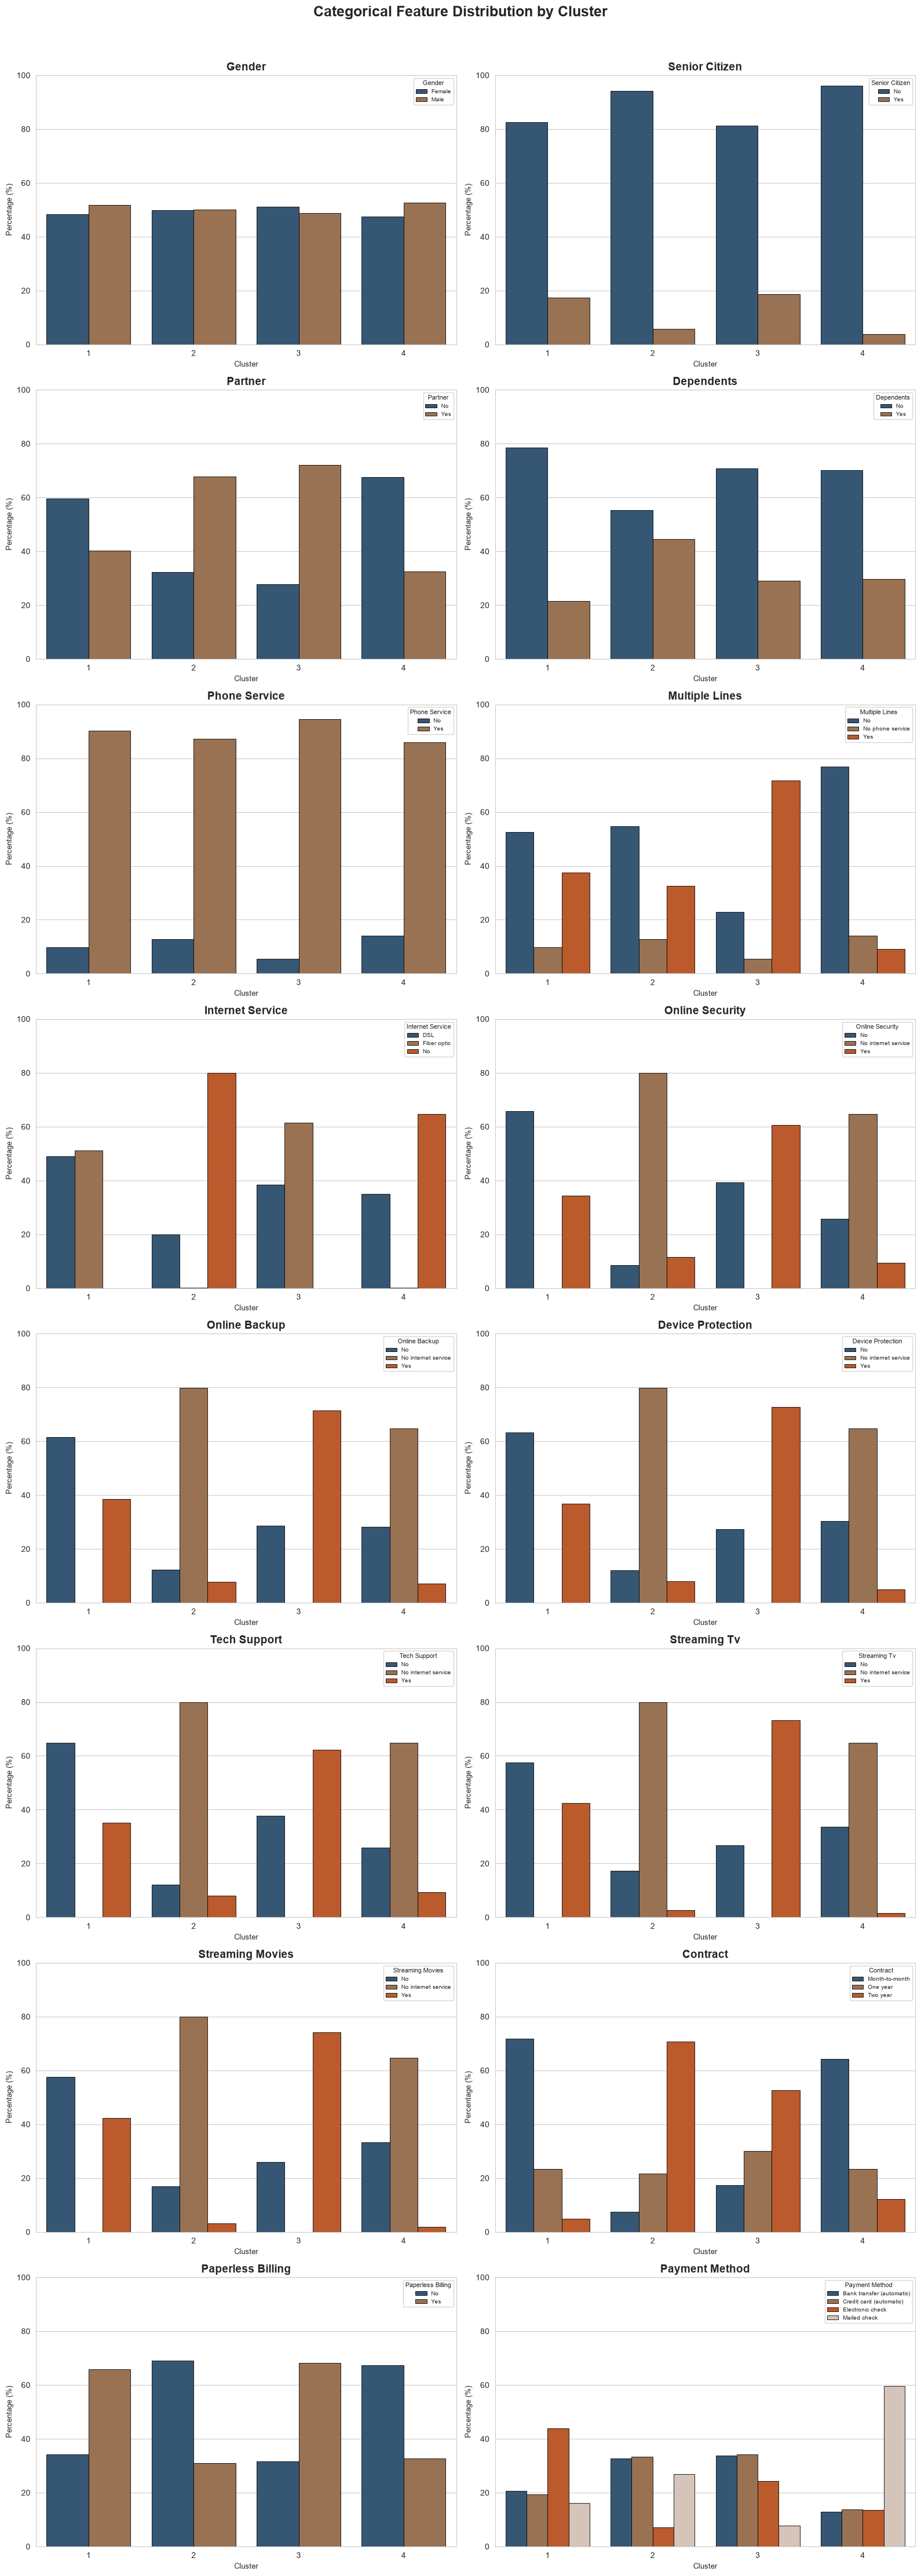

In [38]:
categorical_profile_by_cluster(non_churned_profiled)

#### Non-Churned (Retained) Customers: Cluster Profiles

The retained group was segmented into 4 clusters (labeled 1, 2, 3, 4):

| Feature | Cluster 1 | Cluster 2 | Cluster 3 | Cluster 4 |
|---------|-----------|-----------|-----------|-----------|
| Number of Customers | 1551 (30.0%) | 805 (15.6%) | 1629 (31.5%) | 1189 (23.0%) |
| Avg Tenure (months) | Medium (~23 months) | Long (~56 months) | Long (~61 months) | Short (~12 months) |
| Avg Monthly Charges | High ($73.40) | Low ($26.40) | High ($90.90) | Low ($28.30) |
| Avg Total Charges | Medium ($1,644.60) | Medium ($1,478.70) | High ($5,573.00) | Low ($314.40) |
| Internet Service | ~49% DSL / ~51% Fiber optic | ~80% No internet | ~38% DSL / ~62% Fiber optic | ~35% DSL / ~65% No internet |
| Contract | ~72% Month-to-month | ~71% Two year | ~52% Two year / ~30% One year | ~64% Month-to-month |
| Payment Method | ~44% Electronic check | ~33% Credit card / ~33% Bank transfer | ~34% Credit card / ~34% Bank transfer | ~60% Mailed check |
| Online Security / Tech Support | ~65% "No" | ~80% "No internet service" | ~39–38% "No" / 60–62% "Yes" | ~26% "No" / ~65% "No internet service" |
| Paperless Billing | ~66% Yes | ~31% Yes | ~68% Yes | ~33% Yes |
| Senior Citizen | ~17% Yes | ~6% Yes | ~19% Yes | ~4% Yes |
| Partner / Dependents | ~40% partner; ~22% dependents | ~68% partner; ~45% dependents | ~72% partner; ~29% dependents | ~32% partner; ~30% dependents |


**Key takeaways for retained customers:**

* **Cluster 3** is the "ideal" loyal customer: very long tenure (~5 years), very high monthly charges, overwhelmingly on one-year or two-year contracts, heavy adoption of value-added services (online security, tech support, device protection, online backup, streaming), and pays via automatic bank transfer or credit card. These are **high-value, high-loyalty** customers.

* **Cluster 2** is also very loyal but low-engagement: very long tenure (~56 months), very low monthly charges, mostly no internet service (~80%), overwhelmingly on two-year contracts (~71%), and pays via automatic methods. These likely represent phone-only customers on long-term plans who don't use digital services.

* **Cluster 1** is a "risk" segment among retained customers: medium tenure (~23 months), high charges (mix of fiber optic and DSL), mostly month-to-month contracts (~72%), heavy electronic check payments (~44%), and low adoption of value-added services (~65% don't have online security). Their profile closely mirrors the "at-risk" churned cluster (Cluster 3 in the churned analysis), suggesting they could be future churn candidates.

* **Cluster 4** represents recently-acquired, low-engagement customers: very short tenure (~12 months), low monthly charges, high proportion of no-internet service (~65%), mailed-check payments (~60%), and mostly month-to-month contracts (~64%). They haven't churned yet, but their short tenure and lack of contract lock-in make them potentially vulnerable.


---

### Churn Indicators

Key churn indicators:

1. **Month-to-month contracts** seem to be the strongest churn signal. Every churned cluster is ~93-98% month-to-month, while the most loyal retained cluster (Cluster 3) is predominantly fixed year contracts ~52% two-year/30% one-year. The retained "risk" segment (Cluster 1) that mirrors churned customers is ~72% month-to-month.

2. **Fiber optic + high charges + low tenure** = high-risk combo. Churned Clusters 2 and 3 (74% of all churners) are overwhelmingly fiber optic with high monthly charges. Retained Cluster 3 also has fiber optic and high charges, but the difference is tenure (~5 years vs. ~9 months) and heavy add-on adoption, suggesting fiber/high-price customers only stay if they are also locked into longer contracts and using value-added services.

3. **Lack of value-added services** (online security, tech support) tracks closely with churn. Churned clusters range between 61-90% "No" on these services, while the most stable retained cluster (Cluster 3) shows 60-62% "Yes." Low engagement with these services appears to correlate with disengagement/churn risk generally.

4. **Electronic check payment** is overrepresented among churners. Churned Clusters 2 and 3 lean heavily electronic check (53-69%), while loyal retained customers (Clusters 2 and 3) favor automatic payment methods (credit card/bank transfer, ~33-34% each). Manual payment methods may signal lower commitment or a customer more prone to friction/dropout.

5. **Short tenure + no contract lock-in + high charges** seems to be a churn risk. Retained Cluster 4 has short tenure (~12 months) similar to churned Clusters 1 and 3, but low charges and heavy no-internet/mailed-check usage seem to keep them stable. The combination of short tenure with fiber/high pricing and month-to-month terms appears more dangerous, not tenure by itself.

**Extra note:**

Retained Cluster 1 is the clearest "watchlist" segment out of the retained customer base. The characteristics of this cluster include: 
 - Mid tenure 
 - High charges 
 - Month-to-month 
 - Electronic check 
 - Low add-on adoption
 
which closely resembles the highest-risk churned cluster, making it the most actionable group for proactive retention efforts.

## Predictive modelling: churn risk scores

Clustering told us *who* the at-risk groups look like. Now we build a supervised model to score **individual** customers, so we can deliver:
- a **Top-500 mailer list** of the customers most likely to churn (deliverable 3), and
- a **churn-risk score for every remaining customer** for the service team (deliverable 4).

In [25]:
# Imports for the modelling section
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
import os

# Build the modelling table.
# Drop: IDs / location (not predictive), churn_reason (only known AFTER a customer
# churns, so using it would be leakage), and the target column itself.
drop_cols = ['customerid', 'city', 'zip_code', 'churn_reason', 'churn_value']
X = df.drop(columns=drop_cols)
y = df['churn_value']

# Split columns into numeric vs categorical for preprocessing.
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print('Numeric features    :', num_cols)
print('Categorical features:', len(cat_cols))

Numeric features    : ['tenure_months', 'monthly_charges', 'total_charges']
Categorical features: 16


In [26]:
# Preprocessing: scale numeric columns, one-hot encode categoricals.
# Kept inside a ColumnTransformer + Pipeline so it is fit on the training data
# only (never on the test set) - this prevents data leakage.
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

# Hold out 20% as a test set the model never sees during training/tuning.
# stratify=y keeps the ~27% churn rate in both halves; random_state makes it repeatable.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape, ' Overall churn rate:', round(y.mean(), 3))

Train: (5634, 19)  Test: (1409, 19)  Overall churn rate: 0.265


In [27]:
# Compare a simple baseline (Logistic Regression) against a Random Forest using
# 5-fold stratified cross-validation. We score on ROC-AUC because the classes are
# imbalanced and we care about *ranking* customers by risk, not just the 50% cut-off.
# class_weight='balanced' tells each model that missing a churner matters more.
candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                   random_state=42),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, clf in candidates.items():
    pipe = Pipeline([('pre', preprocess), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f'{name:22s} CV ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})')

Logistic Regression    CV ROC-AUC = 0.859 (+/- 0.012)


Random Forest          CV ROC-AUC = 0.840 (+/- 0.010)


In [28]:
# Tune the Random Forest a little with GridSearchCV (small grid to keep it quick),
# then keep the best pipeline. It refits on the whole training set automatically.
param_grid = {
    'clf__max_depth': [None, 15],
    'clf__min_samples_leaf': [1, 5],
}
rf_pipe = Pipeline([('pre', preprocess),
                    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                   random_state=42))])
search = GridSearchCV(rf_pipe, param_grid, cv=cv, scoring='roc_auc', n_jobs=1)
search.fit(X_train, y_train)
model = search.best_estimator_
print('Best params    :', search.best_params_)
print('Best CV ROC-AUC:', round(search.best_score_, 3))

Best params    : {'clf__max_depth': None, 'clf__min_samples_leaf': 5}
Best CV ROC-AUC: 0.861


In [29]:
# Evaluate the tuned model on the held-out test set (never seen in training/tuning).
proba = model.predict_proba(X_test)[:, 1]   # predicted probability of churn
pred = model.predict(X_test)

print(classification_report(y_test, pred, target_names=['Stayed', 'Churned']))
print('Test ROC-AUC:', round(roc_auc_score(y_test, proba), 3))
# Sanity check: a 'predict nobody churns' baseline would score this accuracy -
print('Baseline (predict everyone stays) accuracy:', round(1 - y_test.mean(), 3))

              precision    recall  f1-score   support

      Stayed       0.90      0.76      0.82      1035
     Churned       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

Test ROC-AUC: 0.853
Baseline (predict everyone stays) accuracy: 0.735


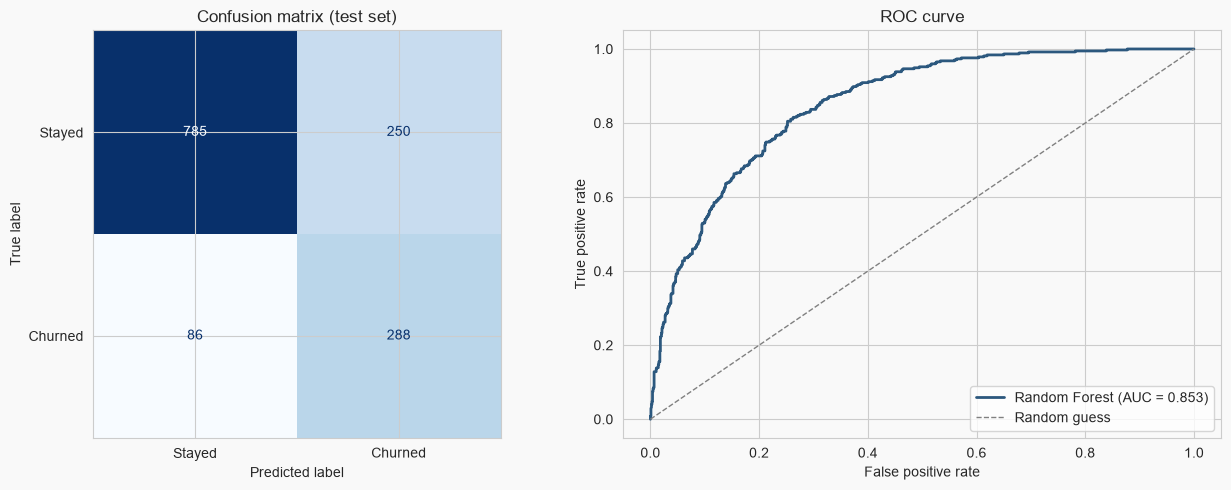

In [30]:
# Visual evaluation: confusion matrix + ROC curve.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG_COLOUR)

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion matrix (test set)')

fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, color=PALETTE[0], lw=2,
             label=f'Random Forest (AUC = {roc_auc_score(y_test, proba):.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='grey', lw=1, label='Random guess')
axes[1].set_xlabel('False positive rate'); axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve'); axes[1].legend(loc='lower right')
axes[1].set_facecolor(BG_COLOUR)
plt.tight_layout(); plt.show()

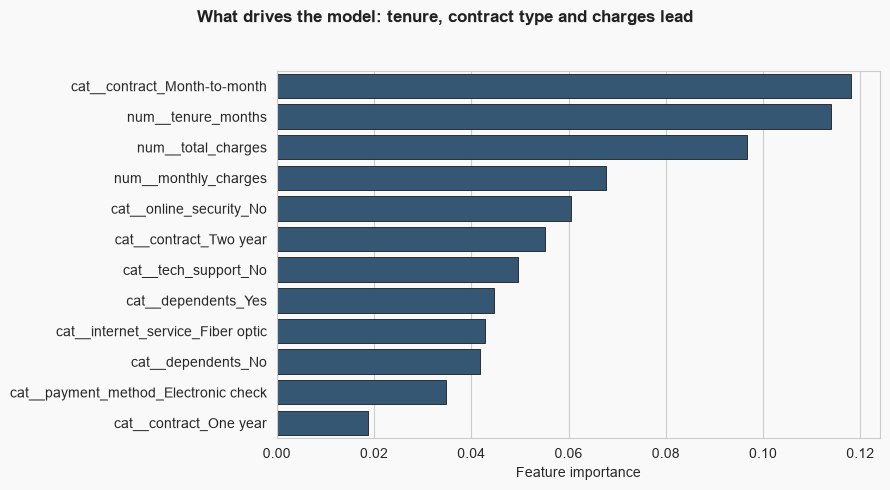

In [31]:
# Which features drive the model? Pull the one-hot names out of the fitted preprocessor.
feature_names = model.named_steps['pre'].get_feature_names_out()
importances = pd.Series(model.named_steps['clf'].feature_importances_, index=feature_names)
top = importances.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG_COLOUR); ax.set_facecolor(BG_COLOUR)
sns.barplot(x=top.values, y=top.index, color=PALETTE[0], ax=ax, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature importance'); ax.set_ylabel('')
for spine in ax.spines.values(): spine.set_color('#cccccc')
fig.suptitle('What drives the model: tenure, contract type and charges lead',
             fontsize=12, fontweight='bold', color='#222222', x=0.5, y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

### Deliverable 4 - churn risk score for every remaining customer

In [32]:
# Score every customer, then keep the ones who haven't churned yet.
# NOTE: this scores some customers the model trained on, so the probabilities are
# slightly optimistic - acceptable for a ranking / triage tool at this level.
df['churn_probability'] = model.predict_proba(X)[:, 1].round(4)
df['risk_score'] = (df['churn_probability'] * 100).round().astype(int)   # 0-100, easy to read
df['risk_band'] = pd.cut(df['churn_probability'], bins=[0, 0.3, 0.6, 1.0],
                         labels=['Low', 'Medium', 'High'], include_lowest=True)

remaining = df[df['churn_value'] == 0].copy()
remaining = remaining.sort_values('churn_probability', ascending=False)

os.makedirs('outputs', exist_ok=True)
risk_cols = ['customerid', 'risk_score', 'risk_band', 'churn_probability',
             'tenure_months', 'contract', 'internet_service', 'monthly_charges']
remaining[risk_cols].to_csv('outputs/churn_risk_scores.csv', index=False)

print(f'Scored {len(remaining):,} remaining customers -> outputs/churn_risk_scores.csv')
print(remaining['risk_band'].value_counts().reindex(['High', 'Medium', 'Low']).to_string())
remaining[risk_cols].head()

Scored 5,174 remaining customers -> outputs/churn_risk_scores.csv
risk_band
High       651
Medium    1254
Low       3269


,customerid,risk_score,risk_band,churn_probability,tenure_months,contract,internet_service,monthly_charges
4341,2545-EBUPK,96,High,0.9643,2,Month-to-month,Fiber optic,84.05
4030,5542-TBBWB,96,High,0.9552,1,Month-to-month,Fiber optic,69.90
4845,8161-QYMTT,95,High,0.9492,7,Month-to-month,Fiber optic,94.10
3732,4927-WWOOZ,94,High,0.9437,2,Month-to-month,Fiber optic,91.45
2215,1452-VOQCH,93,High,0.9345,1,Month-to-month,Fiber optic,75.10


### Deliverable 3 - Top-500 at-risk mailer list

In [33]:
# The 500 highest-risk customers who are still active. Expected mailer uptake is 20%.
top500 = remaining.head(500).copy()
top500.insert(0, 'rank', range(1, len(top500) + 1))

mailer_cols = ['rank', 'customerid', 'risk_score', 'risk_band', 'churn_probability',
               'tenure_months', 'contract', 'monthly_charges']
top500[mailer_cols].to_csv('outputs/top_500_at_risk.csv', index=False)

expected_saved = len(top500) * 0.20
print(f'Top-500 list saved -> outputs/top_500_at_risk.csv')
print(f'Mean churn probability in the list: {top500["churn_probability"].mean():.1%}')
print(f'At the expected 20% uptake, about {expected_saved:.0f} customers could be retained.')
top500[mailer_cols].head()

Top-500 list saved -> outputs/top_500_at_risk.csv
Mean churn probability in the list: 75.0%
At the expected 20% uptake, about 100 customers could be retained.


,rank,customerid,risk_score,risk_band,churn_probability,tenure_months,contract,monthly_charges
4341,1,2545-EBUPK,96,High,0.9643,2,Month-to-month,84.05
4030,2,5542-TBBWB,96,High,0.9552,1,Month-to-month,69.90
4845,3,8161-QYMTT,95,High,0.9492,7,Month-to-month,94.10
3732,4,4927-WWOOZ,94,High,0.9437,2,Month-to-month,91.45
2215,5,1452-VOQCH,93,High,0.9345,1,Month-to-month,75.10


### Outputs delivered

- **`outputs/churn_risk_scores.csv`** - churn probability, a 0-100 risk score and a Low / Medium / High band for every remaining customer (deliverable 4), for the customer-service team to use on live calls.
- **`outputs/top_500_at_risk.csv`** - the 500 highest-risk active customers for the mailer campaign (deliverable 3).

## Summary & recommendations

**The problem.** About **27%** of customers churn, concentrated in a recognisable profile.

**Who leaves (deliverable 1).** Typically **month-to-month** customers on **fibre** with high monthly charges, **low tenure**, paying by **electronic check**, and **without protective add-ons** (online security, tech support). Gender is not a factor. They mainly leave for **competitors** and over **service/support** - not raw price.

**What keeps them (deliverable 2).** A **term contract** (biggest lever), **online security**, **tech support**, and **automatic payment**.
> **Incentive recommendation:** pay the new-customer team a **$2.50 commission for every customer they sign up to online security** - the single sign-up metric with the largest retention effect (churn ~15% with it vs ~42% without).

**Segmentation.** K-means finds a high-risk churner archetype (**Churned Cluster 3**, ~51% of churners) and a retained **watchlist** (Retained Cluster 1) that mirrors it.

**The model (deliverables 3 & 4).** A tuned Random Forest reaches **ROC-AUC ~0.85** on held-out data. It produces the **Top-500 mailer list** (~100 customers retained at the expected 20% uptake) and a **0-100 risk score + Low/Medium/High band** for every remaining customer.

**Recommended actions:**
1. Launch the **Top-500 mailer** with an online-security offer.
2. Move **month-to-month customers onto term contracts** - the single biggest lever.
3. **Fix the support experience** - a top-3 churn reason and very addressable.
4. Give the **customer-service team the risk scores** to use live on calls.